In [1]:
import sys
import os

# Add the parent directory to the system path
sys.path.append(os.path.abspath(os.path.join('..')))
sys.path.append(os.path.abspath(os.path.join('../..')))

In [2]:
import torch
import os
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output, display

from lpn_mrs.datasets import MRSDataset
from lpn_mrs.networks import LPN, LPN_cond, LPN_cond_encode_nn

In [3]:
from sklearn.decomposition import PCA
from scipy.spatial import KDTree

In [4]:
# Visualize true distribution using PCA
true_dataset = MRSDataset(root='../data', split='train', data_type='low_lipid')
all_samples = np.array([true_dataset[i] for i in range(len(true_dataset))])

mean = np.mean(all_samples, axis=0)
centered_samples = all_samples - mean

pca = PCA(n_components=2)
true_proj = pca.fit_transform(centered_samples) 
pc_vector = pca.components_

print(true_proj.shape)
print(pc_vector.shape)

(500, 2)
(2, 512)


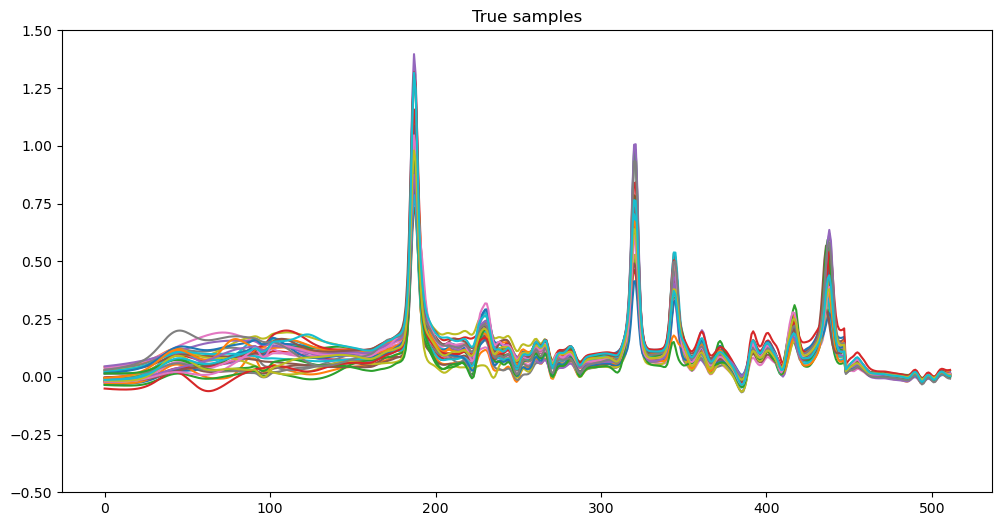

In [5]:
plt.figure(figsize=(12,6))
for i in range(30):
    plt.plot(all_samples[i,:])
plt.title('True samples')
plt.ylim(-0.5, 1.5)
plt.show()

In [6]:
noise_init = 0.2
noise_final = 0.05
num_stage = 5
noise_schedule = np.linspace(noise_init, noise_final, num_stage)
noise_schedule

array([0.2   , 0.1625, 0.125 , 0.0875, 0.05  ])

In [7]:
x0 = np.mean(np.array([true_dataset[i] for i in range(len(true_dataset))]), axis=0)
n_samples = 30

3. Langevin Sampling for LPN trained encoding

In [19]:
kernel = 3
hidden = 64
sigma_min = 0.05
sigma_max = 0.2
max_iter = 500
model_name = 'LPN_cond_encode_nn'

model = LPN_cond_encode_nn(in_dim = 1, hidden_c=1, hidden=hidden, kernel=kernel, beta=10, alpha=1e-6)
model.load_state_dict(torch.load(f"../weights/{model_name.lower()}_mrs_h_{hidden}_k_{kernel}_n_({sigma_min}_{sigma_max})/LPN_best.pt"))

<All keys matched successfully>

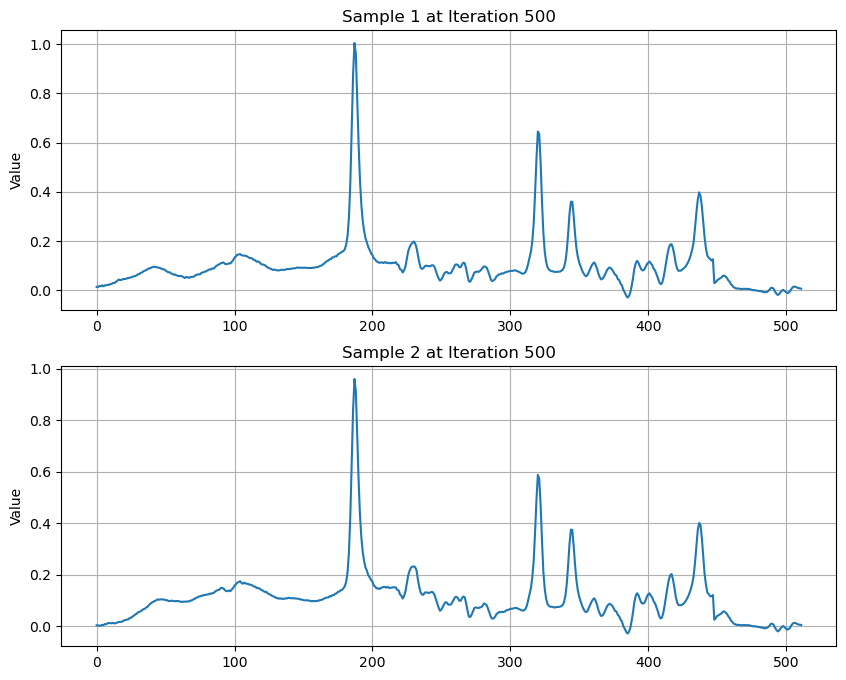

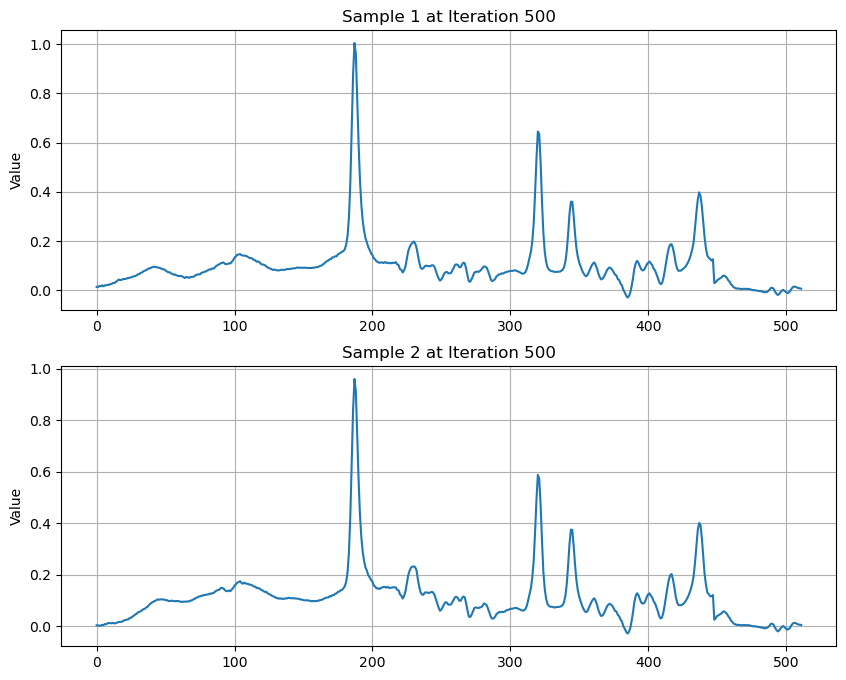

In [20]:
x_lpn_encode = np.tile(x0, (n_samples, 1))
x_lpn_encode = torch.tensor(x_lpn_encode).unsqueeze(1)

projections_lpn_encode = []

plt.ion()  # Enable interactive mode for real-time plotting
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

for it in range(max_iter):
    current_sample = x_lpn_encode.squeeze(1).detach().cpu().numpy()
    proj = (current_sample - mean) @ pc_vector.T
    projections_lpn_encode.append(proj)
    
    clear_output(wait=True)

    for i in range(2):
        axs[i].cla()  # Clear axes
        axs[i].plot(current_sample[i]) 
        axs[i].set_title(f'Sample {i + 1} at Iteration {it + 1}') 
        axs[i].set_ylabel('Value')
        axs[i].grid(True)

    display(fig)

    stage_id = it // (max_iter // num_stage)
    sigma = noise_schedule[stage_id]

    noise_levels = torch.full((n_samples,1), sigma)
    x_lpn_encode = model(x_lpn_encode + torch.randn_like(x_lpn_encode) * sigma * np.sqrt(2), noise_levels)

# After the loop, keep the plot open
plt.ioff()  # Disable interactive mode
plt.show()

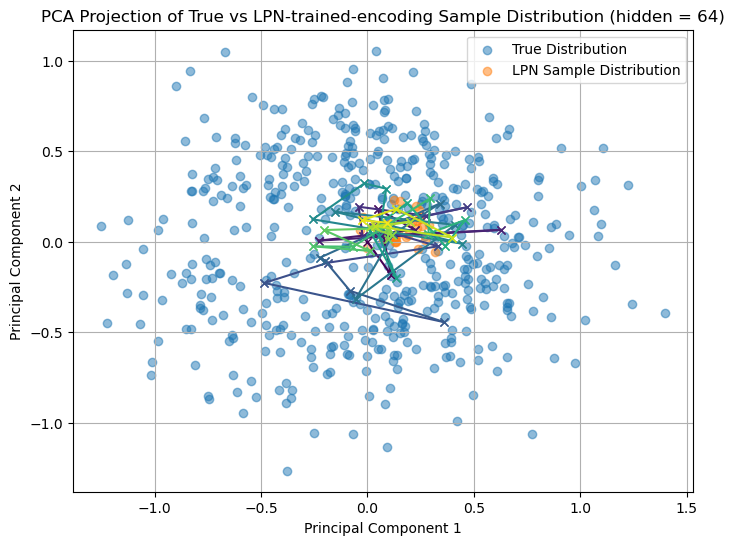

In [21]:
proj_lpn_encode = np.array(projections_lpn_encode)
colors = np.linspace(0, 1, max_iter)
step_size = 10

plt.figure(figsize=(8, 6))
plt.scatter(true_proj[:, 0], true_proj[:, 1], alpha=0.5, label='True Distribution')
plt.scatter(proj_lpn_encode[-1][:, 0], proj_lpn_encode[-1][:, 1], alpha=0.5, label='LPN Sample Distribution')

for i in range(0, max_iter, step_size):
    plt.plot(proj_lpn_encode[i:(i + step_size + 1):step_size,10,0], proj_lpn_encode[i:(i + step_size + 1):step_size, 10, 1], marker='x', color=plt.cm.viridis(colors[int(i)]))

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title(f'PCA Projection of True vs LPN-trained-encoding Sample Distribution (hidden = {hidden})')
plt.legend()
plt.grid(True)
plt.show()

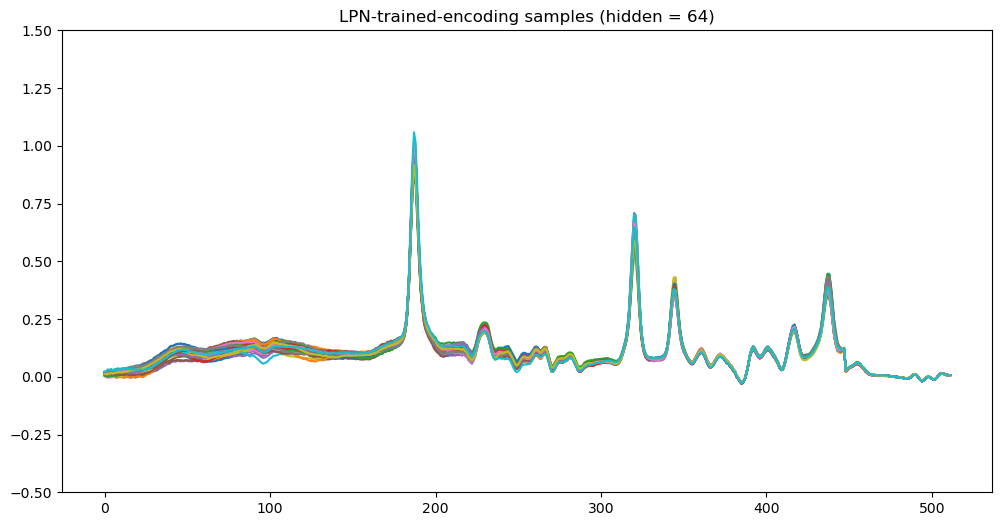

In [22]:
x_lpn_encode_np = x_lpn_encode.squeeze(1).detach().numpy()
plt.figure(figsize=(12,6))
for i in range(len(x_lpn_encode_np)):
    plt.plot(x_lpn_encode_np[i,:])
plt.title(f'LPN-trained-encoding samples (hidden = {hidden})')
plt.ylim(-0.5, 1.5)
plt.show()

4.1 Langevin Sampling for LPN fixed encoding for all kernel

In [ ]:
hidden = 64
sigma_min = 0.05
sigma_max = 0.2
max_iter = 500
model_name = 'LPN_cond'

<All keys matched successfully>

In [10]:
x_lpn_res = {}
for kernel in [3,11,33,101]:
    print(f"Sampling {kernel}")
    model = LPN_cond(in_dim = 1, hidden_c=1, hidden=hidden, kernel=kernel, beta=10, alpha=1e-6)
    model.load_state_dict(torch.load(f"../weights/{model_name.lower()}_mrs_h_{hidden}_k_{kernel}_n_({sigma_min}_{sigma_max})/LPN_best.pt"))

    x_lpn = np.tile(x0, (n_samples, 1))
    x_lpn = torch.tensor(x_lpn).unsqueeze(1)

    projections_lpn = []

    for it in range(max_iter):
        current_sample = x_lpn.squeeze(1).detach().cpu().numpy()
        proj = (current_sample - mean) @ pc_vector.T
        projections_lpn.append(proj)

        stage_id = it // (max_iter // num_stage)
        sigma = noise_schedule[stage_id]

        noise_levels = torch.full((n_samples,1), sigma)
        x_lpn = model(x_lpn + torch.randn_like(x_lpn) * sigma * np.sqrt(2), noise_levels)

    proj_lpn = np.array(projections_lpn)

    x_lpn_res[kernel] = {
        'proj_lpn': proj_lpn,
        'x_lpn': x_lpn.squeeze(1).detach().numpy()
    }  

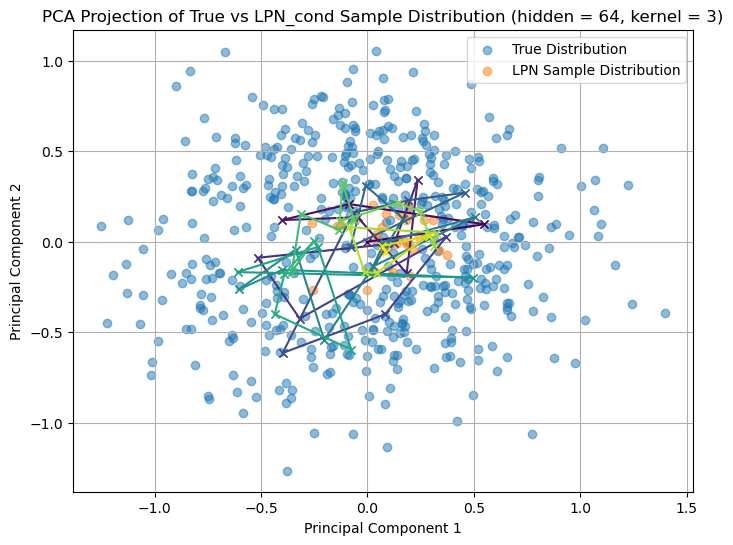

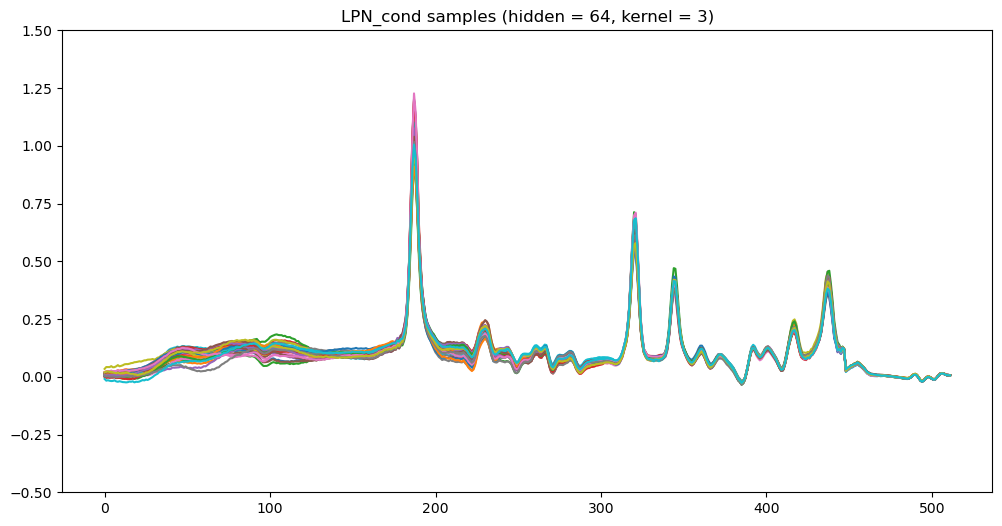

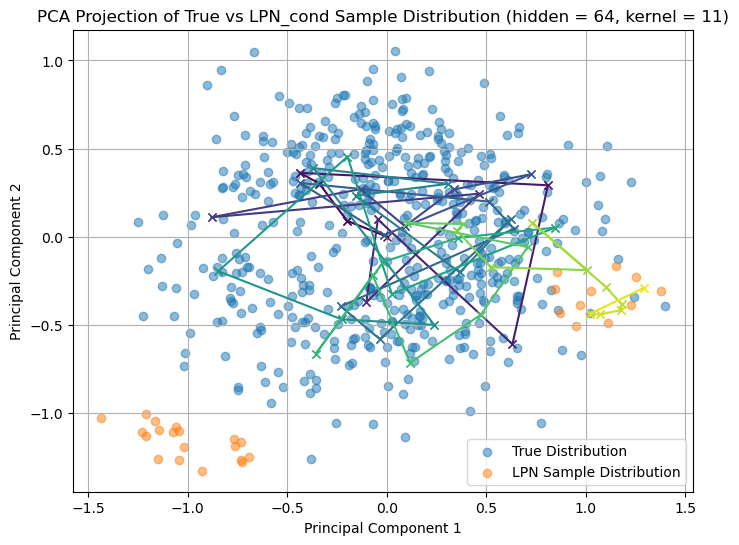

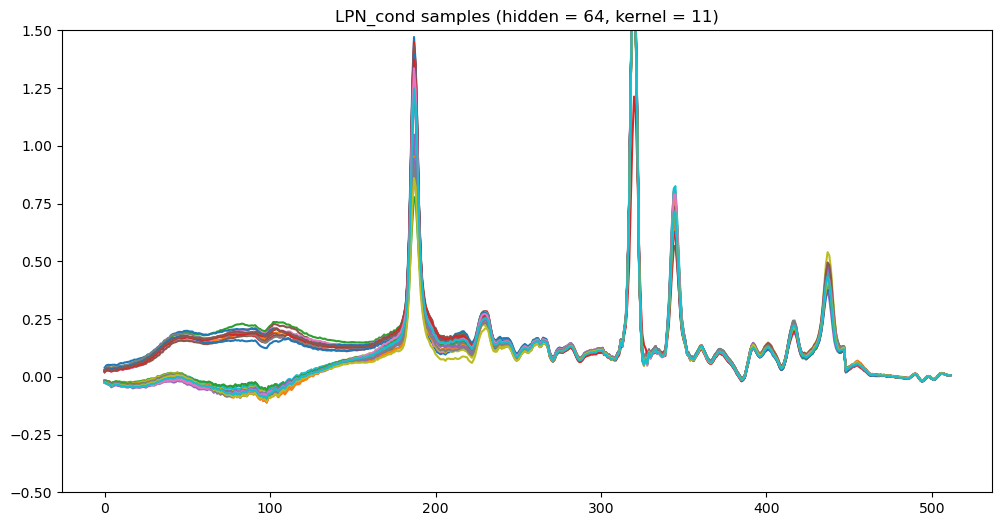

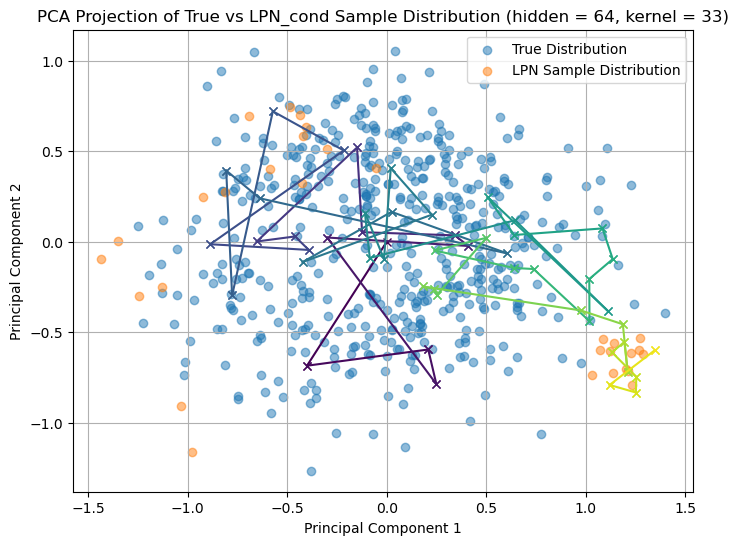

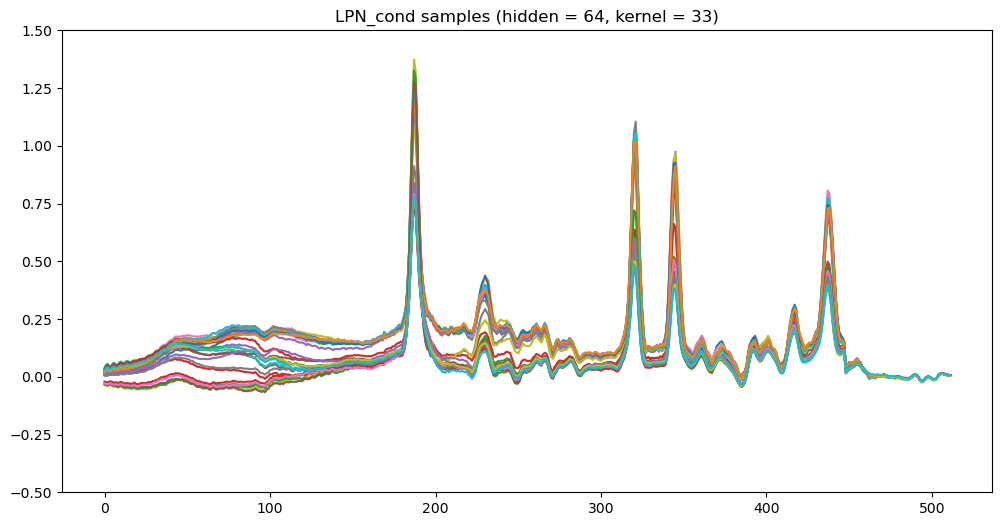

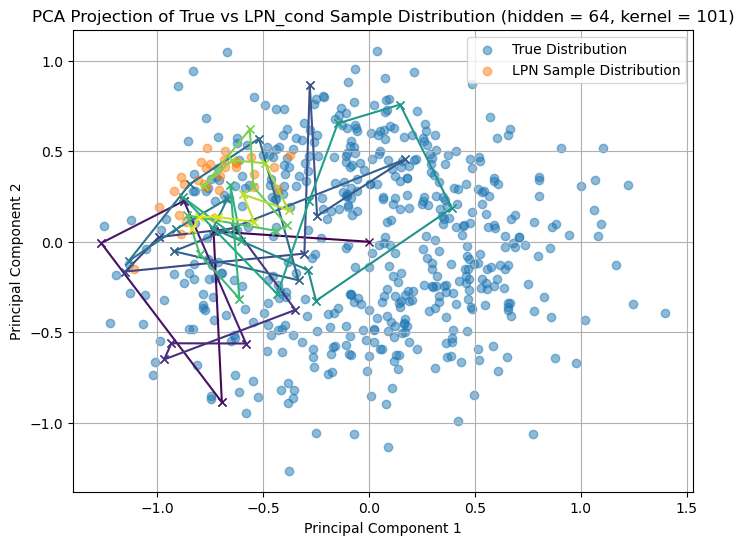

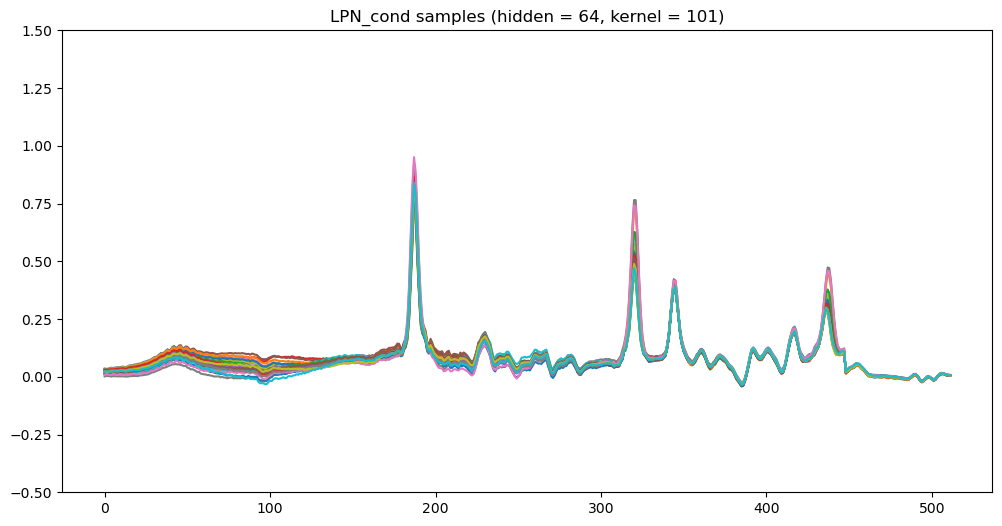

In [11]:
for kernel in [3,11,33,101]:
    proj_lpn = x_lpn_res[kernel]['proj_lpn']
    x_lpn = x_lpn_res[kernel]['x_lpn']

    colors = np.linspace(0, 1, max_iter)
    step_size = 10

    plt.figure(figsize=(8, 6))
    plt.scatter(true_proj[:, 0], true_proj[:, 1], alpha=0.5, label='True Distribution')
    plt.scatter(proj_lpn[-1][:, 0], proj_lpn[-1][:, 1], alpha=0.5, label='LPN Sample Distribution')

    for i in range(0, max_iter, step_size):
        plt.plot(proj_lpn[i:(i + step_size + 1):step_size,10,0], proj_lpn[i:(i + step_size + 1):step_size, 10, 1], marker='x', color=plt.cm.viridis(colors[int(i)]))

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f'PCA Projection of True vs LPN_cond Sample Distribution (hidden = {hidden}, kernel = {kernel})')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12,6))
    for i in range(len(x_lpn)):
        plt.plot(x_lpn[i,:])
    plt.title(f'LPN_cond samples (hidden = {hidden}, kernel = {kernel})')
    plt.ylim(-0.5, 1.5)
    plt.show()

4.2 Langevin Sampling for LPN fixed encoding k=11

In [23]:
kernel = 11
hidden = 64
sigma_min = 0.05
sigma_max = 0.2
max_iter = 500
model_name = 'LPN_cond'

model = LPN_cond(in_dim = 1, hidden_c=1, hidden=hidden, kernel=kernel, beta=10, alpha=1e-6)
model.load_state_dict(torch.load(f"../weights/{model_name.lower()}_mrs_h_{hidden}_k_{kernel}_n_({sigma_min}_{sigma_max})/LPN_best.pt"))

<All keys matched successfully>

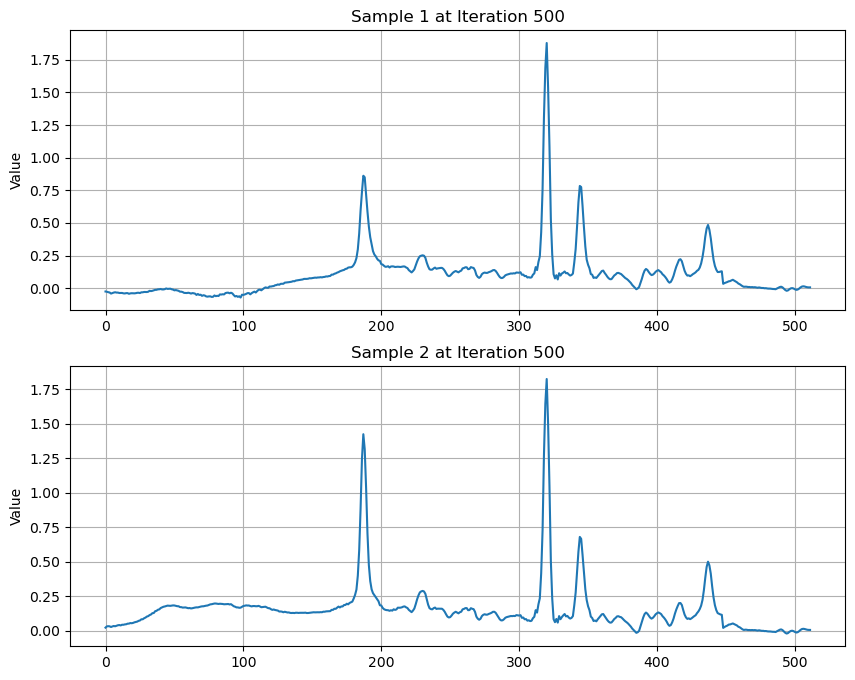

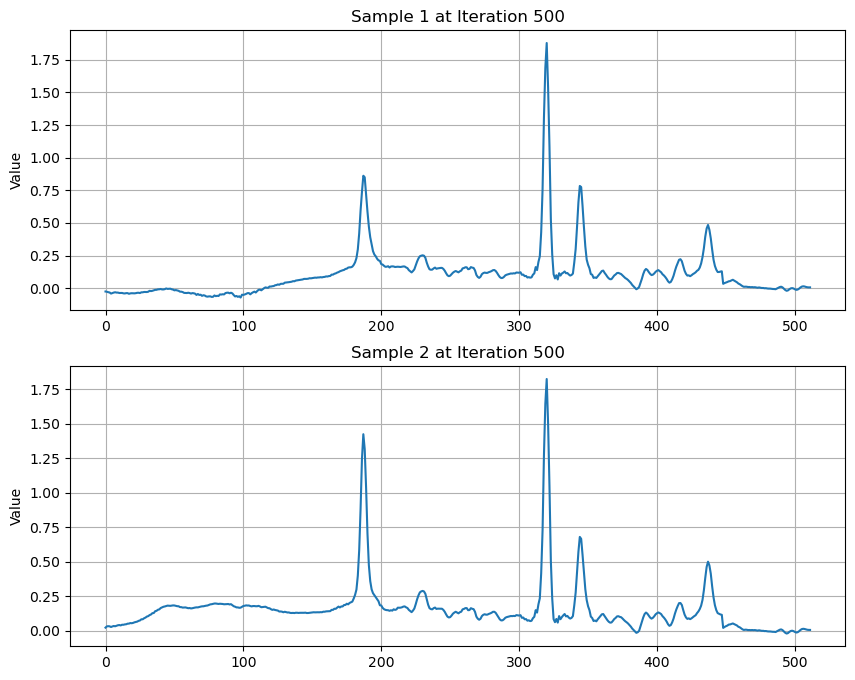

In [24]:
x_lpn_k11 = np.tile(x0, (n_samples, 1))
x_lpn_k11 = torch.tensor(x_lpn_k11).unsqueeze(1)

projections_lpn_k11 = []

plt.ion()  # Enable interactive mode for real-time plotting
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

for it in range(max_iter):
    current_sample = x_lpn_k11.squeeze(1).detach().cpu().numpy()
    proj = (current_sample - mean) @ pc_vector.T
    projections_lpn_k11.append(proj)
    
    clear_output(wait=True)

    for i in range(2):
        axs[i].cla()  # Clear axes
        axs[i].plot(current_sample[i]) 
        axs[i].set_title(f'Sample {i + 1} at Iteration {it + 1}') 
        axs[i].set_ylabel('Value')
        axs[i].grid(True)

    display(fig)

    stage_id = it // (max_iter // num_stage)
    sigma = noise_schedule[stage_id]

    noise_levels = torch.full((n_samples,1), sigma)
    x_lpn_k11 = model(x_lpn_k11 + torch.randn_like(x_lpn_k11) * sigma * np.sqrt(2), noise_levels)

# After the loop, keep the plot open
plt.ioff()  # Disable interactive mode
plt.show()

5.1 Langevin sampling for LPN with for all kernels

In [8]:
hidden = 64
sigma = 0.1
max_iter = 500
model_name = 'LPN'

In [9]:
x_lpn_uncond_res = {}
for kernel in [3,11,33]:
    print(f"Sampling {kernel}")
    model = LPN(in_dim = 1, hidden=hidden, kernel=kernel, beta=10, alpha=1e-6)
    model.load_state_dict(torch.load(f"../weights/{model_name.lower()}_mrs_h_{hidden}_k_{kernel}_n_{sigma}/LPN_best.pt"))

    x_lpn = np.tile(x0, (n_samples, 1))
    x_lpn = torch.tensor(x_lpn).unsqueeze(1)

    projections_lpn = []

    for it in range(max_iter):
        current_sample = x_lpn.squeeze(1).detach().cpu().numpy()
        proj = (current_sample - mean) @ pc_vector.T
        projections_lpn.append(proj)

        x_lpn = model(x_lpn + torch.randn_like(x_lpn) * sigma * np.sqrt(2))

    proj_lpn = np.array(projections_lpn)

    x_lpn_uncond_res[kernel] = {
        'proj_lpn': proj_lpn,
        'x_lpn': x_lpn.squeeze(1).detach().numpy()
    } 

Sampling 3
Sampling 11
Sampling 33


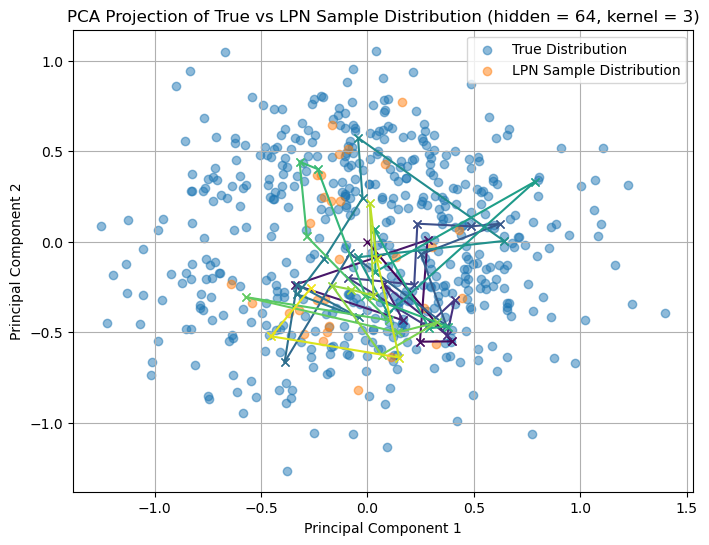

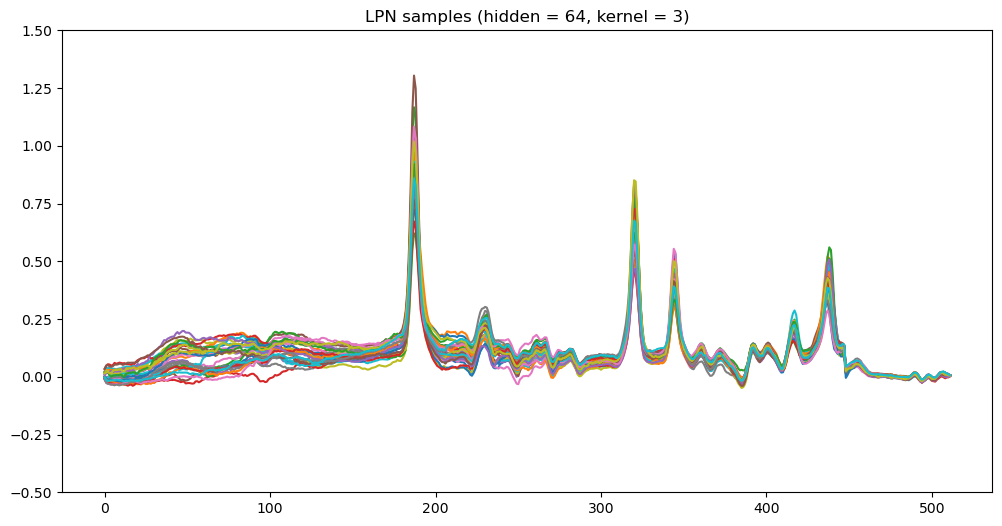

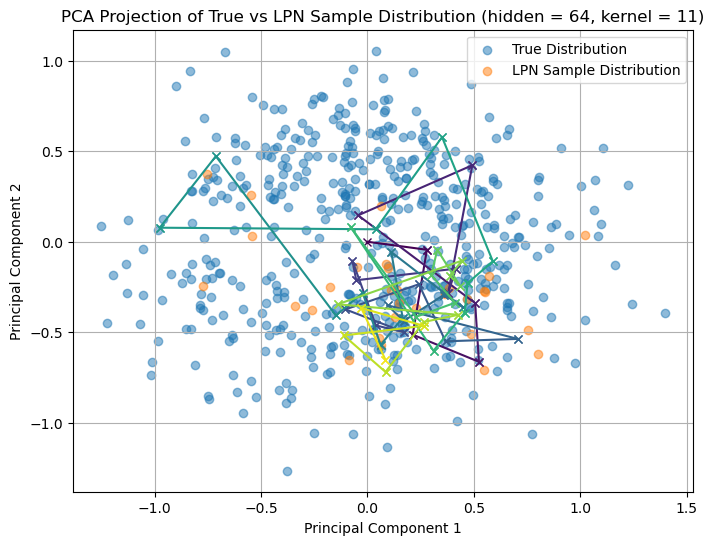

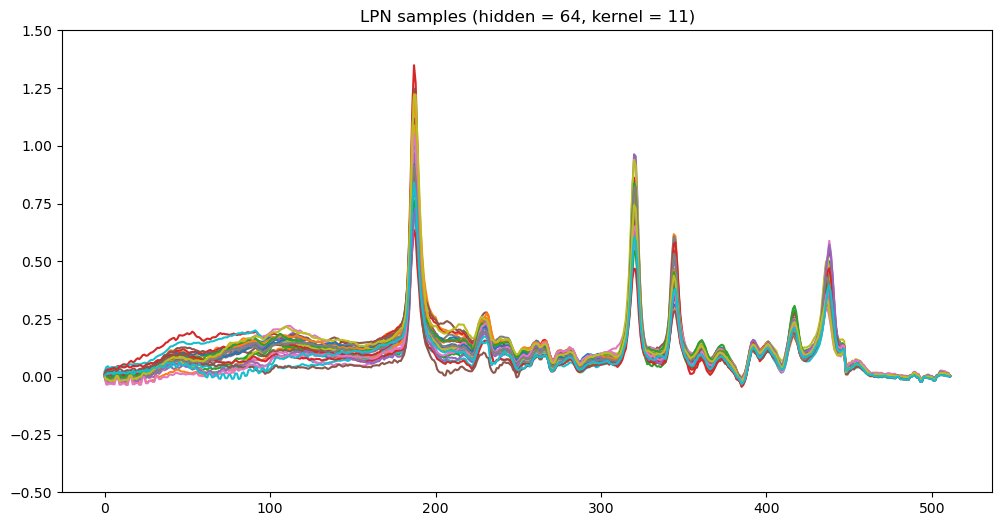

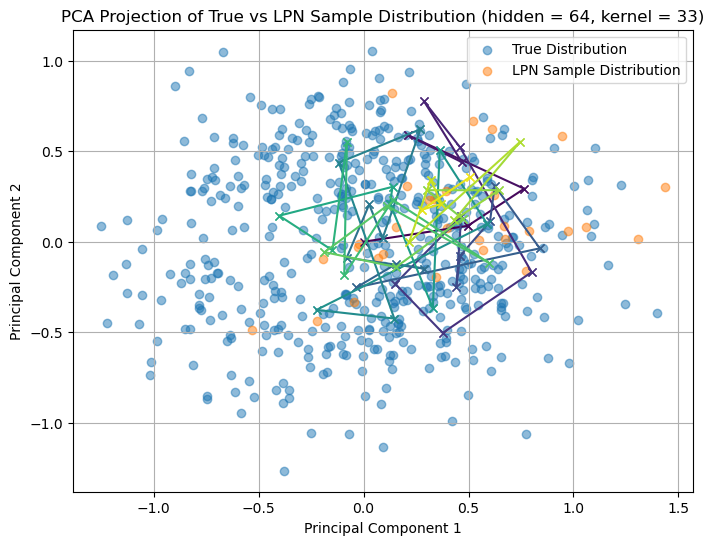

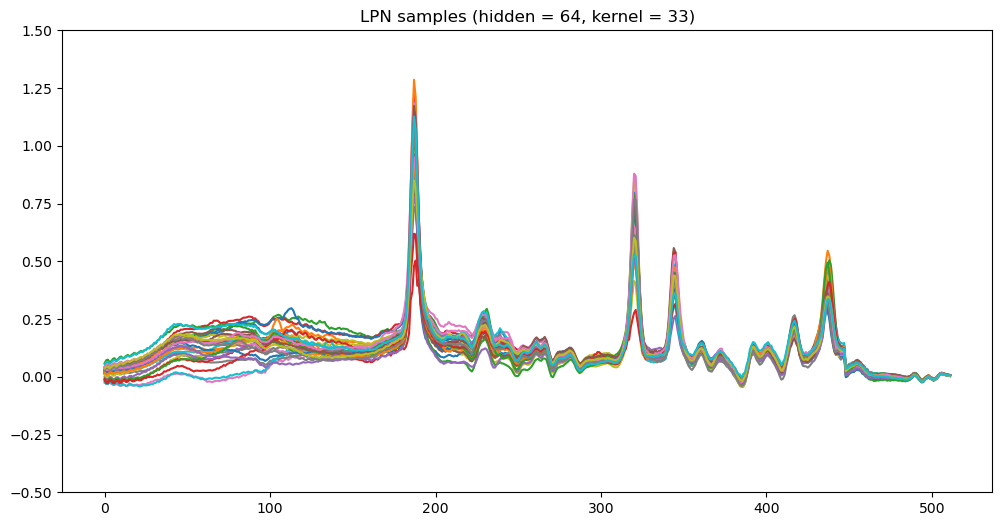

In [11]:
for kernel in [3,11,33]:
    proj_lpn = x_lpn_uncond_res[kernel]['proj_lpn']
    x_lpn = x_lpn_uncond_res[kernel]['x_lpn']

    colors = np.linspace(0, 1, max_iter)
    step_size = 10

    plt.figure(figsize=(8, 6))
    plt.scatter(true_proj[:, 0], true_proj[:, 1], alpha=0.5, label='True Distribution')
    plt.scatter(proj_lpn[-1][:, 0], proj_lpn[-1][:, 1], alpha=0.5, label='LPN Sample Distribution')

    for i in range(0, max_iter, step_size):
        plt.plot(proj_lpn[i:(i + step_size + 1):step_size,10,0], proj_lpn[i:(i + step_size + 1):step_size, 10, 1], marker='x', color=plt.cm.viridis(colors[int(i)]))

    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.title(f'PCA Projection of True vs LPN Sample Distribution (hidden = {hidden}, kernel = {kernel})')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(12,6))
    for i in range(len(x_lpn)):
        plt.plot(x_lpn[i,:])
    plt.title(f'LPN samples (hidden = {hidden}, kernel = {kernel})')
    plt.ylim(-0.5, 1.5)
    plt.show()

5.2 Langevin sampling for LPN with fixed stepsize k=3

In [25]:
kernel = 3
hidden = 64
sigma = 0.1
max_iter = 500
model_name = 'LPN'

model = LPN(in_dim = 1, hidden=hidden, kernel=kernel, beta=10, alpha=1e-6)
model.load_state_dict(torch.load(f"../weights/{model_name.lower()}_mrs_h_{hidden}_k_{kernel}_n_{sigma}/LPN_best.pt"))

<All keys matched successfully>

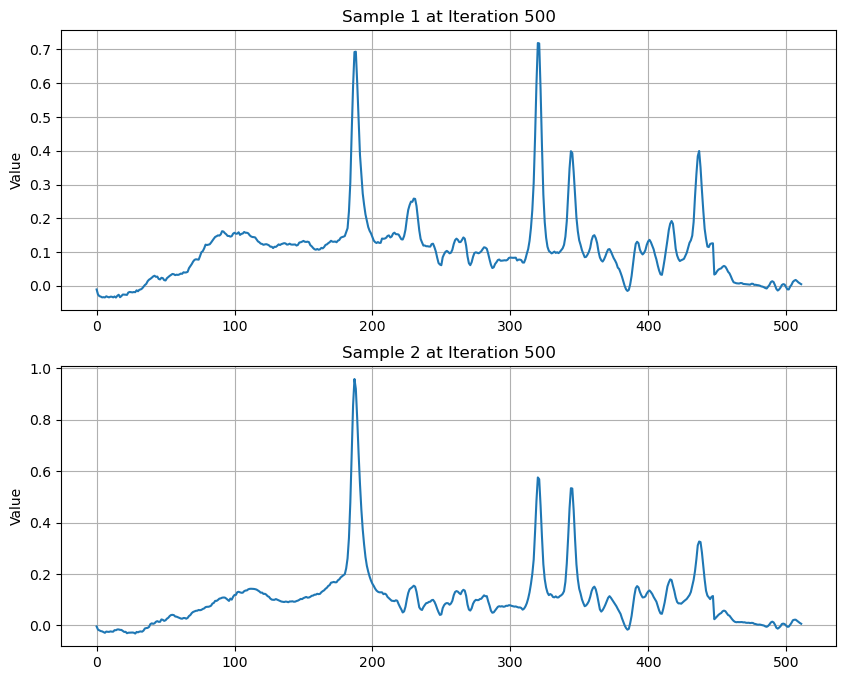

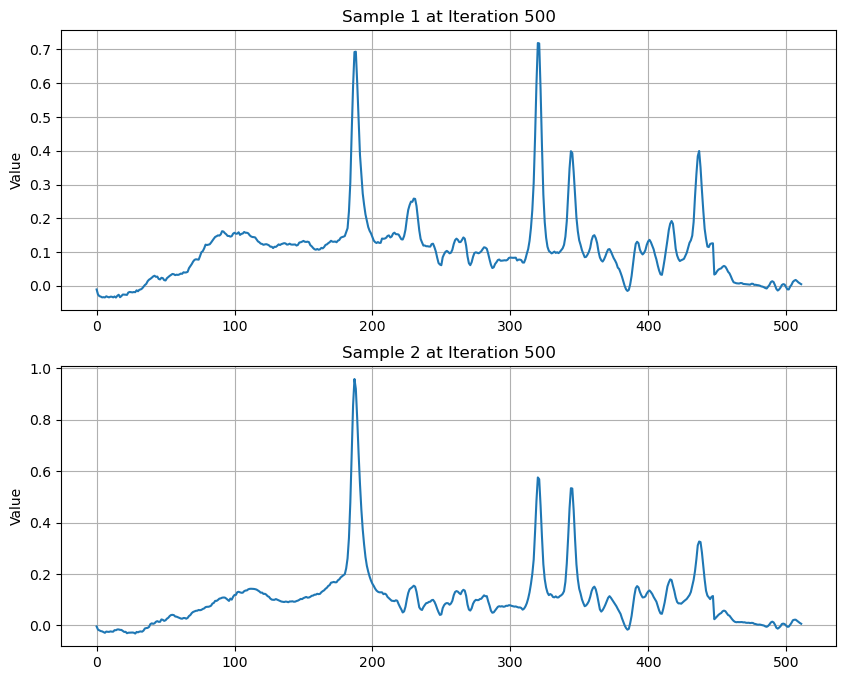

In [26]:
x_lpn_k3_uncond = np.tile(x0, (n_samples, 1))
x_lpn_k3_uncond = torch.tensor(x_lpn_k3_uncond).unsqueeze(1)

projections_lpn_k3_uncond = []

plt.ion()  # Enable interactive mode for real-time plotting
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

for it in range(max_iter):
    current_sample = x_lpn_k3_uncond.squeeze(1).detach().cpu().numpy()
    proj = (current_sample - mean) @ pc_vector.T
    projections_lpn_k3_uncond.append(proj)
    
    clear_output(wait=True)

    for i in range(2):
        axs[i].cla()  # Clear axes
        axs[i].plot(current_sample[i]) 
        axs[i].set_title(f'Sample {i + 1} at Iteration {it + 1}') 
        axs[i].set_ylabel('Value')
        axs[i].grid(True)

    display(fig)

    x_lpn_k3_uncond = model(x_lpn_k3_uncond + torch.randn_like(x_lpn_k3_uncond) * sigma * np.sqrt(2))

# After the loop, keep the plot open
plt.ioff()  # Disable interactive mode
plt.show()